# Arabic Handwritten Word Recognition — YOLO + CRNN
**Run all cells top-to-bottom. Do not skip any cell.**

### Architecture
- **YOLO** (YOLOv8s, single class) detects character bounding boxes in the word image
- **CRNN classifier** (CNN + BiLSTM) classifies each cropped character
  - The BiLSTM treats image columns as a time sequence, capturing stroke patterns
  - Trained on isolated-character datasets: AHAWP + my_chars + Arabic MNIST
- Detected boxes are sorted right-to-left (Arabic reading order)
- Final output: sequence of character names
- CLAHE preprocessing applied to every character crop before classification


## Cell 1 — Install dependencies

In [1]:
import subprocess, sys
pkgs = ['tensorflow','opencv-python-headless','numpy','matplotlib',
        'tqdm','scikit-learn','ultralytics']
for p in pkgs:
    subprocess.run([sys.executable,'-m','pip','install','-q',p], check=False)
print('All packages ready.')


All packages ready.


## Cell 2 — Imports and constants

In [4]:
import os, cv2, random, warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import torch
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from ultralytics import YOLO
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
tf.random.set_seed(SEED); torch.manual_seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
def detect_root() -> Path:
    candidates = [
        Path.cwd(),
        Path('/mnt/f/newbach/Arabic-Handwritten-Characters-Recognition-using-CNN'),
        Path('F:/newbach/Arabic-Handwritten-Characters-Recognition-using-CNN'),
    ]
    for p in candidates:
        if (p / 'isolated_alphabets_per_alphabet').exists() and (p / 'my_dataset').exists():
            return p
    cur = Path.cwd().resolve()
    for parent in [cur] + list(cur.parents):
        if (parent / 'ArabicWordRecognition_v3.ipynb').exists() and (parent / 'isolated_alphabets_per_alphabet').exists():
            return parent
        if (parent / 'isolated_alphabets_per_alphabet').exists() and (parent / 'my_dataset').exists():
            return parent
    return Path.cwd().resolve()

ROOT        = detect_root()
AHAWP_DIR   = ROOT / 'isolated_alphabets_per_alphabet'
MY_CHARS    = ROOT / 'my_chars'
MY_DATASET  = ROOT / 'my_dataset'
MNIST_TRAIN = ROOT / 'arabic-chars-mnist' / 'train'
MNIST_TEST  = ROOT / 'arabic-chars-mnist' / 'test'

# ── Character classes (must match data.yaml order) ───────────────────────────
CLASS_NAMES = [
    'ain','alef','beh','dad','dal','feh','ghain','hah','hamza','heh',
    'jeem','kaf','khah','lam','meem','noon','qaf','reh','sad','seen',
    'sheen','tah','teh','teh_marbota','thal','theh','waw','yeh','zah','zain'
]
NUM_CLASSES  = len(CLASS_NAMES)   # 30

# ── CRNN character classifier hyper-params ───────────────────────────────────
IMG_SIZE     = 64      # character crop size (64×64)
BATCH_SIZE   = 32
CNN_EPOCHS   = 60
LR           = 1e-3

# ── YOLO detection threshold used at inference ───────────────────────────────
YOLO_CONF    = 0.25
YOLO_IOU     = 0.40

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = '0' if torch.cuda.is_available() else 'cpu'
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'TF GPU : {gpus[0].name}')
else:
    print('TF: CPU only')
print(f'YOLO device: {DEVICE}')
print(f'TensorFlow {tf.__version__}   Torch {torch.__version__}')


TF: CPU only
YOLO device: cpu
TensorFlow 2.18.0   Torch 2.5.1+cpu


## Cell 3 — Load isolated character datasets for CRNN training

In [5]:
def load_image_folder_dataset(root_dir, class_names):
    """
    Load images from a folder-per-class structure.
    Folder name must match (or start with) a class name.
    Returns list of (image_path, class_index) tuples.
    """
    root = Path(root_dir)
    if not root.exists():
        print(f'  Skipping (not found): {root}')
        return []
    items = []
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    for folder in sorted(root.iterdir()):
        if not folder.is_dir(): continue
        # Match folder name to a class — exact or prefix match
        fname = folder.name.lower().strip()
        cls_idx = None
        if fname in name_to_idx:
            cls_idx = name_to_idx[fname]
        else:
            for name, idx in name_to_idx.items():
                if fname.startswith(name) or name.startswith(fname):
                    cls_idx = idx; break
        if cls_idx is None:
            continue
        for img_path in folder.iterdir():
            if img_path.suffix.lower() in ('.jpg','.jpeg','.png','.bmp'):
                items.append((img_path, cls_idx))
    return items


print('Loading character datasets...')
ahawp_items  = load_image_folder_dataset(AHAWP_DIR,    CLASS_NAMES)
chars_items  = load_image_folder_dataset(MY_CHARS_DIR, CLASS_NAMES)
mnist_items  = load_image_folder_dataset(MNIST_DIR,    CLASS_NAMES)
all_items    = ahawp_items + chars_items + mnist_items

print(f'AHAWP       : {len(ahawp_items):>6} images')
print(f'my_chars    : {len(chars_items):>6} images')
print(f'Arabic MNIST: {len(mnist_items):>6} images')
print(f'Total       : {len(all_items):>6} images')

# Class distribution
from collections import Counter
dist = Counter(idx for _, idx in all_items)
print('\nClass distribution:')
for i, name in enumerate(CLASS_NAMES):
    bar = '|' * (dist[i] // 50)
    print(f'  {name:<15} {dist[i]:>5}  {bar}')

# Train / val split (90/10)
random.shuffle(all_items)
split     = int(0.9 * len(all_items))
train_items = all_items[:split]
val_items   = all_items[split:]
print(f'\nTrain: {len(train_items)}   Val: {len(val_items)}')


Loading character datasets...
  Skipping (not found): F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\Arabic_MNIST
AHAWP       :  45965 images
my_chars    :    219 images
Arabic MNIST:      0 images
Total       :  46184 images

Class distribution:
  ain              3288  |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  alef                0  
  beh              3302  ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  dad                24  
  dal              1647  ||||||||||||||||||||||||||||||||
  feh              3256  |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  ghain              23  
  hah                27  
  hamza               9  
  heh              3265  |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  jeem             3286  |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  kaf              3285  |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  

## Cell 4 — Preprocessing and augmentation for character crops

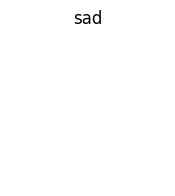

In [9]:
def preprocess_char(img_path_or_array, size=IMG_SIZE):
    """
    Load (or accept) a character image, apply CLAHE, binarise,
    crop to ink bounding box, pad to square, resize to (size,size,1).
    Returns float32 (size, size, 1), ink=1 bg=0.
    """
    if isinstance(img_path_or_array, (str, Path)):
        img = cv2.imread(str(img_path_or_array))
        if img is None: return None
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_path_or_array.copy()
        if gray.ndim == 3: gray = cv2.cvtColor(gray, cv2.COLOR_BGR2GRAY)

    # CLAHE — normalise contrast
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(4,4))
    gray  = clahe.apply(gray)
    # Binarise
    _, bw  = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
    coords = cv2.findNonZero(bw)
    if coords is None: return None
    # Reject near-empty crops
    ink_ratio = np.sum(bw>0) / bw.size
    if ink_ratio < 0.02: return None
    x, y, w, h = cv2.boundingRect(coords)
    roi = gray[y:y+h, x:x+w]
    # Pad to square with 18% margin
    pad  = int(max(h, w) * 0.18)
    side = max(4, h+2*pad, w+2*pad)
    canvas = np.full((side, side), 255, dtype='uint8')
    ox, oy = (side-w)//2, (side-h)//2
    canvas[oy:oy+h, ox:ox+w] = roi
    resized = cv2.resize(canvas, (size, size), interpolation=cv2.INTER_LANCZOS4)
    out = 1.0 - resized.astype('float32') / 255.0   # ink=1 bg=0
    return out[..., np.newaxis]   # (size, size, 1)


def augment_char(img):
    """
    Safe augmentations for isolated Arabic characters.
    No horizontal flip — mirrors Arabic letters.
    """
    x = img.copy().squeeze()
    if random.random() < 0.5:
        x += np.random.normal(0, 0.03, x.shape).astype('float32')
    if random.random() < 0.5:
        x *= random.uniform(0.75, 1.25)
    if random.random() < 0.4:
        angle = random.uniform(-8, 8)
        M = cv2.getRotationMatrix2D((IMG_SIZE/2, IMG_SIZE/2), angle, 1.0)
        x = cv2.warpAffine(x, M, (IMG_SIZE, IMG_SIZE),
                           borderMode=cv2.BORDER_CONSTANT, borderValue=0.0)
    if random.random() < 0.3:
        k  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2,2))
        u8 = (np.clip(x,0,1)*255).astype('uint8')
        x  = cv2.dilate(u8, k).astype('float32') / 255.0
    return np.clip(x, 0, 1)[..., np.newaxis]


# Sanity check
sample_img, sample_cls = train_items[0]
arr = preprocess_char(sample_img)
#print(f'Preprocessed shape: {arr.shape}  class: {CLASS_NAMES[sample_cls]}')
plt.figure(figsize=(2,2))
#plt.imshow(arr.squeeze(), cmap='gray')
plt.title(CLASS_NAMES[sample_cls])
plt.axis('off'); plt.show()


## Cell 5 — CRNN character classifier model

In [23]:
def build_crnn_char_classifier(img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    """
    CRNN for single-character classification.
    The image columns are treated as a time sequence for the BiLSTM,
    capturing stroke direction patterns.

    Input : (batch, img_size, img_size, 1)
    Output: (batch, num_classes)  — softmax probabilities
    """
    inp = keras.Input(shape=(img_size, img_size, 1), name='char_image')

    # ── CNN feature extractor ────────────────────────────────────────────────
    def cnn_block(x, f, pool=(2,2)):
        x = layers.Conv2D(f, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        return layers.MaxPooling2D(pool)(x)

    x = cnn_block(inp,  32)   # → (32,32,32)
    x = cnn_block(x,    64)   # → (16,16,64)
    x = cnn_block(x,   128)   # → ( 8, 8,128)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)   # → ( 8, 8,256)

    # ── Collapse height axis → treat width as time sequence ─────────────────
    # (batch, H, W, C) → mean over H → (batch, W, C)
    x = layers.Lambda(lambda t: tf.reduce_mean(t, axis=1))(x)  # (batch, 8, 256)

    # ── BiLSTM — captures left-to-right stroke patterns ─────────────────────
    x = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.3))(x)
    x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=False, dropout=0.3))(x)

    # ── Classification head ──────────────────────────────────────────────────
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax', name='class_output')(x)

    return keras.Model(inp, out, name='CRNN_CharClassifier')


crnn_clf = build_crnn_char_classifier()
crnn_clf.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
crnn_clf.summary()
print(f'Parameters: {crnn_clf.count_params():,}')


Model: "CRNN_CharClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ char_image (InputLayer)         │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 8, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 8, 256)         │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 989,086 (3.77 MB)

 Trainable params: 988,126 (3.77 MB)

 Non-trainable params: 960 (3.75 KB)

Parameters: 989,086


## Cell 6 — Data generator for character classifier

In [11]:
class CharDataGenerator(keras.utils.Sequence):
    def __init__(self, items, batch_size=BATCH_SIZE, augment=False):
        self.items, self.batch_size, self.augment = items, batch_size, augment
        self.indices = list(range(len(items)))

    def __len__(self):
        return max(1, len(self.items) // self.batch_size)

    def on_epoch_end(self):
        random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch = [self.items[i]
                 for i in self.indices[idx*self.batch_size:(idx+1)*self.batch_size]]
        imgs, lbls = [], []
        for path, cls_idx in batch:
            img = preprocess_char(path)
            if img is None: continue
            if self.augment: img = augment_char(img)
            imgs.append(img)
            lbls.append(cls_idx)
        if not imgs:
            return self.__getitem__((idx+1) % len(self))
        return (np.array(imgs, 'float32'), np.array(lbls, 'int32'))


char_train_gen = CharDataGenerator(train_items, augment=True)
char_val_gen   = CharDataGenerator(val_items,   augment=False)
print(f'Train batches: {len(char_train_gen)}   Val batches: {len(char_val_gen)}')


Train batches: 1298   Val batches: 144


## Cell 7 — Train CRNN character classifier

Epoch 1/60
1298/1298 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - accuracy: 0.3982 - loss: 1.8344
Epoch 1: val_accuracy improved from -inf to 0.65151, saving model to f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\crnn_char_classifier.keras
1298/1298 ━━━━━━━━━━━━━━━━━━━━ 1147s 878ms/step - accuracy: 0.3984 - loss: 1.8340 - val_accuracy: 0.6515 - val_loss: 1.2820 - learning_rate: 0.0010
Epoch 2/60
1298/1298 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8434 - loss: 0.5107
Epoch 2: val_accuracy improved from 0.65151 to 0.88045, saving model to f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\crnn_char_classifier.keras
1298/1298 ━━━━━━━━━━━━━━━━━━━━ 118s 91ms/step - accuracy: 0.8434 - loss: 0.5107 - val_accuracy: 0.8804 - val_loss: 0.3807 - learning_rate: 0.0010
Epoch 3/60
1298/1298 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8895 - loss: 0.3637
Epoch 3: val_accuracy improved from 0.88045 to 0.89278, saving model to f:\newbach\Arabic-Handwritten-Characters-Reco

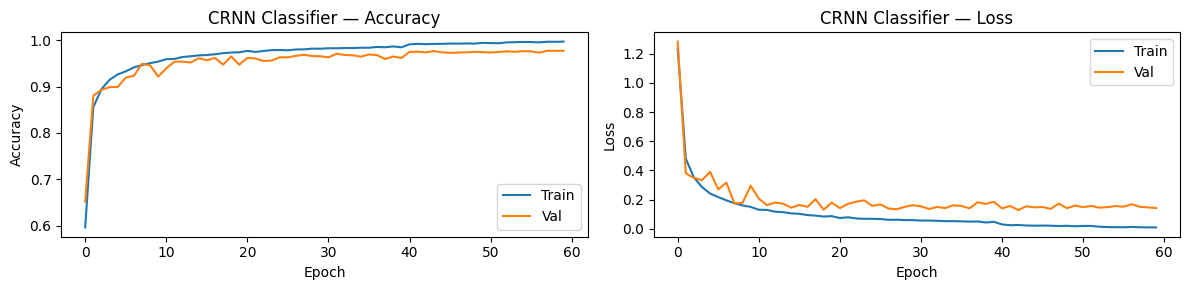

Best model saved to: f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\crnn_char_classifier.keras


In [12]:
CRNN_SAVE = str(ROOT / 'crnn_char_classifier.keras')

callbacks = [
    keras.callbacks.ModelCheckpoint(
        CRNN_SAVE, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5, patience=8,
        min_lr=1e-6, mode='max', verbose=1),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=20,
        restore_best_weights=True, mode='max', verbose=1),
]

history = crnn_clf.fit(
    char_train_gen, validation_data=char_val_gen,
    epochs=CNN_EPOCHS, callbacks=callbacks, verbose=1
)

plt.figure(figsize=(12, 3))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('CRNN Classifier — Accuracy'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('CRNN Classifier — Loss'); plt.legend()
plt.tight_layout(); plt.show()
print(f'Best model saved to: {CRNN_SAVE}')


## Cell 8 — Train YOLO character detector

In [ ]:
import shutil

yaml_path    = MY_DATASET / 'data.yaml'
yolo_run_dir = ROOT / 'my_yolo_yolo_crnn'
yolo_run_name = 'char_detector'

# Clear any old run to avoid reusing stale weights
old_run = yolo_run_dir / yolo_run_name
if old_run.exists():
    shutil.rmtree(old_run)
    print(f'Cleared old run: {old_run}')

yolo = YOLO('yolov8s.pt')
yolo.train(
    data=str(yaml_path),
    epochs=200,
    imgsz=640,
    batch=8,
    patience=40,
    device=DEVICE,
    project=str(yolo_run_dir),
    name=yolo_run_name,
    exist_ok=True,
    workers=0,
    single_cls=True,        # detect 'character' only — CRNN handles classification
    # ── Augmentation (safe for Arabic script) ──────────────────────────────
    degrees=6.0,
    translate=0.08,
    scale=0.3,
    shear=2.0,
    perspective=0.0001,
    flipud=0.0,
    fliplr=0.0,             # NEVER flip — mirrors Arabic letters
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
    erasing=0.0,            # NEVER erase — deletes critical dots
    auto_augment='',
    hsv_h=0.01,
    hsv_s=0.4,
    hsv_v=0.4,
)

YOLO_WEIGHTS = yolo_run_dir / yolo_run_name / 'weights' / 'best.pt'
print(f'YOLO weights exist: {YOLO_WEIGHTS.exists()}')
print(f'Path: {YOLO_WEIGHTS}')


In [19]:
yolo_run_dir = ROOT / 'my_yolo_yolo_crnn'
yolo_run_name = 'char_detector'
yolo_model = YOLO('yolov8s.pt')

YOLO_WEIGHTS = ROOT / 'my_yolo_v3' / yolo_run_name / 'weights' / 'best.pt'


## Cell 9 — Full recognition pipeline (YOLO + CRNN)

In [24]:
# Load trained models (safe to re-run this cell without retraining)
yolo_detector = YOLO(str(YOLO_WEIGHTS))
# Some saved models contain Lambda layers defined with Python lambdas.
# Keras blocks deserialization of anonymous lambdas by default for safety.
# Enable unsafe deserialization here if you trust the saved artifact.
keras.config.enable_unsafe_deserialization()
# Try loading the full model first; if that fails, rebuild architecture and load weights.
try:
    crnn_model = keras.models.load_model(CRNN_SAVE)
    print('Full CRNN model loaded from file.')
except Exception as e:
    print('Full model load failed:', type(e).__name__, str(e))
    print('Rebuilding model architecture and loading weights instead.')
    crnn_model = build_crnn_char_classifier()
    crnn_model.load_weights(CRNN_SAVE)
    print('Weights loaded into rebuilt CRNN model.')


def suppress_bad_boxes(boxes_scores, img_h, img_w, iou_thr=0.45):
    """Remove overlapping and extreme-aspect-ratio boxes."""
    if not boxes_scores: return []
    areas = np.array([(x2-x1)*(y2-y1) for x1,y1,x2,y2,_ in boxes_scores],'float32')
    med   = max(1.0, float(np.median(areas)))
    keep  = []
    for b in boxes_scores:
        x1,y1,x2,y2,s = b
        w,h  = x2-x1, y2-y1
        asp  = w / max(1,h)
        area = w*h
        if area > 2.8*med: continue
        if asp > 3.5 or asp < 0.15: continue
        keep.append(b)
    if not keep: keep = list(boxes_scores)
    # NMS
    keep.sort(key=lambda b: -b[4])
    out = []
    for cand in keep:
        def iou(a,b):
            ix1,iy1=max(a[0],b[0]),max(a[1],b[1])
            ix2,iy2=min(a[2],b[2]),min(a[3],b[3])
            inter=max(0,ix2-ix1)*max(0,iy2-iy1)
            if inter==0: return 0
            aa=(a[2]-a[0])*(a[3]-a[1]);ab=(b[2]-b[0])*(b[3]-b[1])
            return inter/(aa+ab-inter)
        if all(iou(cand[:4],k[:4])<iou_thr for k in out):
            out.append(cand)
    return out


def recognize_word_yolo_crnn(image_path, conf=YOLO_CONF, iou=YOLO_IOU,
                              visualize=True):
    """
    Full pipeline:
      1. YOLO detects character bounding boxes
      2. Each crop is preprocessed with CLAHE
      3. CRNN classifies each crop
      4. Boxes sorted right-to-left (Arabic reading order)
      5. Returns list of character names
    """
    img = cv2.imread(str(image_path))
    if img is None:
        print('Cannot read image.'); return []
    H, W = img.shape[:2]
    annotated = img.copy()

    # ── Step 1: YOLO detection ───────────────────────────────────────────────
    results = yolo_detector(img, conf=conf, iou=iou, verbose=False)[0]
    if len(results.boxes) == 0:
        print('No characters detected.'); return []

    raw_boxes = []
    for box, score in zip(results.boxes,
                          results.boxes.conf.cpu().numpy().tolist()):
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        x1,y1 = max(0,x1), max(0,y1)
        x2,y2 = min(W,x2), min(H,y2)
        if x2-x1 < 8 or y2-y1 < 8: continue
        raw_boxes.append((x1,y1,x2,y2,float(score)))

    filtered = suppress_bad_boxes(raw_boxes, H, W)

    # ── Step 2-3: Crop → CRNN classify ──────────────────────────────────────
    detections = []
    for x1,y1,x2,y2,score in filtered:
        # 10% padding around the crop
        pw = int((x2-x1)*0.10); ph = int((y2-y1)*0.10)
        cx1,cy1 = max(0,x1-pw), max(0,y1-ph)
        cx2,cy2 = min(W,x2+pw), min(H,y2+ph)
        crop = img[cy1:cy2, cx1:cx2]
        if crop.size == 0: continue
        arr  = preprocess_char(crop)
        if arr is None: continue
        preds   = crnn_model.predict(arr[np.newaxis], verbose=0)[0]
        cls_idx = int(np.argmax(preds))
        conf_v  = float(preds[cls_idx])
        detections.append({'box':(x1,y1,x2,y2), 'label':CLASS_NAMES[cls_idx],
                           'conf':conf_v, 'cx':(x1+x2)/2})

    if not detections:
        print('All crops rejected.'); return []

    # ── Step 4: Sort right-to-left ───────────────────────────────────────────
    detections.sort(key=lambda d: -d['cx'])
    char_sequence = [d['label'] for d in detections]

    # ── Step 5: Annotate and visualise ───────────────────────────────────────
    if visualize:
        for d in detections:
            x1,y1,x2,y2 = d['box']
            cv2.rectangle(annotated, (x1,y1),(x2,y2), (0,200,0), 2)
            cv2.putText(annotated, f"{d['label']} {d['conf']:.2f}",
                        (x1, max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX,
                        0.45, (0,0,200), 1)
        plt.figure(figsize=(10, 5))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title('Detected: ' + ' + '.join(char_sequence))
        plt.axis('off'); plt.tight_layout(); plt.show()

    print('Characters:', char_sequence)
    return char_sequence


Full model load failed: NotImplementedError Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 8, 8, 256), dtype=float32, sparse=False, name=keras_tensor_107>',)
  • kwargs={'mask': 'None'}
Rebuilding model architecture and loading weights instead.
Weights loaded into rebuilt CRNN model.


## Cell 10 — Test on validation images

Testing on 0 validation images...



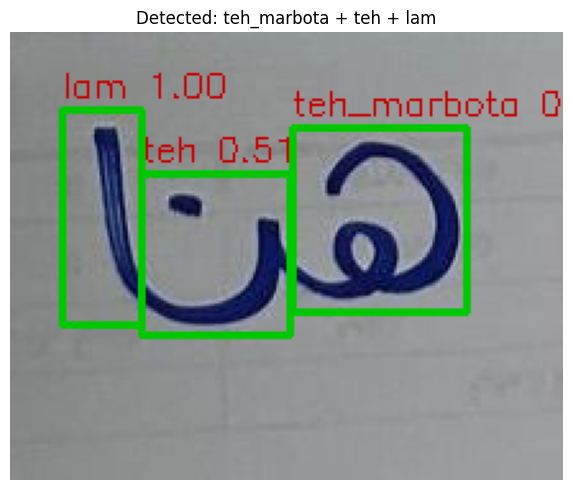

Characters: ['teh_marbota', 'teh', 'lam']
Result: ['teh_marbota', 'teh', 'lam']


In [27]:
# Load validation word images from the YOLO dataset
val_images_dir = MY_DATASET / 'val' / 'images'
val_imgs = sorted(val_images_dir.glob('*.jpg')) + \
           sorted(val_images_dir.glob('*.png'))

print(f'Testing on {min(5, len(val_imgs))} validation images...\n')
for img_path in val_imgs[:5]:
    print(f'Image: {img_path.name}')
    result = recognize_word_yolo_crnn(img_path)
    print()

# ── Test on your own image ────────────────────────────────────────────────
result = recognize_word_yolo_crnn(r'F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\word_test.png')
print('Result:', result)


## Cell 11 — Quick accuracy check on validation set

In [28]:
# Load ground truth from YOLO label files for comparison
val_labels_dir = MY_DATASET / 'val' / 'labels'

def edit_distance(ref, hyp):
    r, h = list(ref), list(hyp)
    dp = np.zeros((len(r)+1, len(h)+1), dtype=int)
    for i in range(len(r)+1): dp[i,0] = i
    for j in range(len(h)+1): dp[0,j] = j
    for i in range(1,len(r)+1):
        for j in range(1,len(h)+1):
            cost = 0 if r[i-1]==h[j-1] else 1
            dp[i,j] = min(dp[i-1,j]+1, dp[i,j-1]+1, dp[i-1,j-1]+cost)
    return dp[len(r),len(h)]


total_ed, total_chars = 0, 0
for img_path in tqdm(val_imgs, desc='Evaluating'):
    lbl_path = val_labels_dir / (img_path.stem + '.txt')
    if not lbl_path.exists(): continue
    # Ground truth: read boxes, sort right-to-left
    boxes = []
    for line in lbl_path.read_text().splitlines():
        p = line.strip().split()
        if len(p) >= 5:
            boxes.append((int(p[0]), float(p[1])))
    if not boxes: continue
    boxes.sort(key=lambda b: -b[1])
    true_seq  = [CLASS_NAMES[b[0]] for b in boxes]
    pred_seq  = recognize_word_yolo_crnn(img_path, visualize=False)
    total_ed    += edit_distance(true_seq, pred_seq)
    total_chars += len(true_seq)

cer = total_ed / max(1, total_chars)
print(f'\nCharacter Error Rate : {cer:.4f}')
print(f'Character Accuracy   : {(1-cer)*100:.1f}%')


Evaluating: 0it [00:00, ?it/s]


Character Error Rate : 0.0000
Character Accuracy   : 100.0%
